In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import openpyxl

# Count of Imaging Activity by Modality

In [3]:
# Load Excel files and correct header
file_path = "Table-1-2024-25-Modality-Provider-Counts-2025-07-24-XLSX-199KB.xlsx"
modality_df_24_25 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

file_path = "DID-Table-1-2023-24-Modality-Provider-Counts-xlsx-190KB.xlsx"
modality_df_23_24 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

file_path = "Table-1-2022-23-Modality-Provider-Counts-XLSX-190KB.xlsx"
modality_df_22_23 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

file_path = "Table-1-2021-22-Modality-Provider-Counts-2022-12-15-xlsx-191KB.xlsx"
modality_df_21_22 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

file_path = "DID-Table-1-2020-21-Modality-Provider-Counts-xlsx-181KB.xlsx"
modality_df_20_21 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

In [4]:
modality_df_24_25.head()
modality_df_23_24.head()
modality_df_22_23.head()
modality_df_21_22.head()
modality_df_20_21.head()

,Unnamed: 0,Region,Org Code,Provider name,Modality,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Jan,Feb,Mar,Year
0,NaN,-,-,ENGLAND,Computerized Axial Tomography,275195,366505,431550,494525,485155,501935,519630,497025,493055,487675,475275,546945,5574475
1,NaN,-,-,ENGLAND,Diagnostic Ultrasonography,365510,448385,608900,715715,673670,769095,795365,787860,749705,721845,726515,859145,8221710
2,NaN,-,-,ENGLAND,Fluoroscopy,29790,40315,55480,67385,64465,74620,75060,72535,68200,58895,61855,76785,745385
3,NaN,-,-,ENGLAND,Magnetic Resonance Imaging,100585,145315,214630,261870,264410,280730,300030,293610,276845,279020,275510,316410,3008970
4,NaN,-,-,ENGLAND,Medical Photography,1685,2870,4255,4805,4535,5095,4825,4560,4560,4395,4375,5345,51305


In [5]:
modality_df_24_25.info()
modality_df_23_24.info()
modality_df_22_23.info()
modality_df_21_22.info()
modality_df_20_21.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     0 non-null      float64
 1   Region         1254 non-null   object 
 2   Org Code       1246 non-null   object 
 3   Provider name  1246 non-null   object 
 4   Modality       1246 non-null   object 
 5   Apr            1173 non-null   object 
 6   May            1185 non-null   object 
 7   Jun            1166 non-null   object 
 8   Jul            1146 non-null   object 
 9   Aug            1149 non-null   object 
 10  Sep            1163 non-null   object 
 11  Oct            1173 non-null   object 
 12  Nov            1181 non-null   object 
 13  Dec            1172 non-null   object 
 14  Jan            1155 non-null   object 
 15  Feb            1161 non-null   object 
 16  Mar            1134 non-null   object 
 17  Year           1246 non-null   object 
dtypes: float

In [6]:
# Unique categories for each file
sorted_modality_24_25 = sorted(modality_df_24_25["Modality"].dropna().unique())
sorted_modality_23_24 = sorted(modality_df_23_24["Modality"].dropna().unique())
sorted_modality_22_23 = sorted(modality_df_22_23["Modality"].dropna().unique())
sorted_modality_21_22 = sorted(modality_df_21_22["Modality"].dropna().unique())
sorted_modality_20_21 = sorted(modality_df_20_21["Modality"].dropna().unique())

In [7]:
# Store your dataframes in a dictionary
modality_dfs = {
    "2024_25": modality_df_24_25,
    "2023_24": modality_df_23_24,
    "2022_23": modality_df_22_23,
    "2021_22": modality_df_21_22,
    "2020_21": modality_df_20_21,
}

# Dictionary to store counts
modality_counts_per_year = {}

for year, df in modality_dfs.items():
    counts = df["Modality"].value_counts(dropna=False).sort_values(ascending=False)
    modality_counts_per_year[year] = counts

# Example: print each year’s counts
for year, counts in modality_counts_per_year.items():
    print(f"\n=== {year} ===")
    print(counts)



=== 2024_25 ===
Modality
Diagnostic Ultrasonography                        191
Plain Radiography                                 189
Magnetic Resonance Imaging                        186
Computerized Axial Tomography                     175
Fluoroscopy                                       164
Nuclear Medicine Procedure                        130
Single Photon Emission Computerized Tomography    107
Positron Emission Tomography                       87
Medical Photography                                17
NaN                                                11
Name: count, dtype: int64

=== 2023_24 ===
Modality
Diagnostic Ultrasonography                        189
Plain Radiography                                 189
Magnetic Resonance Imaging                        187
Computerized Axial Tomography                     175
Fluoroscopy                                       166
Nuclear Medicine Procedure                        124
Single Photon Emission Computerized Tomography    106
Posi

In [8]:
# Count unique providers per year
unique_providers_per_year = {}
for year, df in modality_dfs.items():
    unique_providers_per_year[year] = df["Provider name"].nunique()

# Print results
for year, count in unique_providers_per_year.items():
    print(f"{year}: {count} unique providers")

2024_25: 161 unique providers
2023_24: 160 unique providers
2022_23: 166 unique providers
2021_22: 167 unique providers
2020_21: 164 unique providers


In [9]:
for year, df in modality_dfs.items():
    print(f"\nColumns in {year}:")
    print(df.columns.tolist())


Columns in 2024_25:
['Unnamed: 0', 'Region', 'Org Code', 'Provider name', 'Modality', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']

Columns in 2023_24:
['Unnamed: 0', 'Region', 'Org Code', 'Provider name', 'Modality', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']

Columns in 2022_23:
['Unnamed: 0', 'Region', 'Org Code', 'Provider name', 'Modality', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']

Columns in 2021_22:
['Unnamed: 0', 'Region', 'Org Code', 'Provider name', 'Modality', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']

Columns in 2020_21:
['Unnamed: 0', 'Region', 'Org Code', 'Provider name', 'Modality', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']


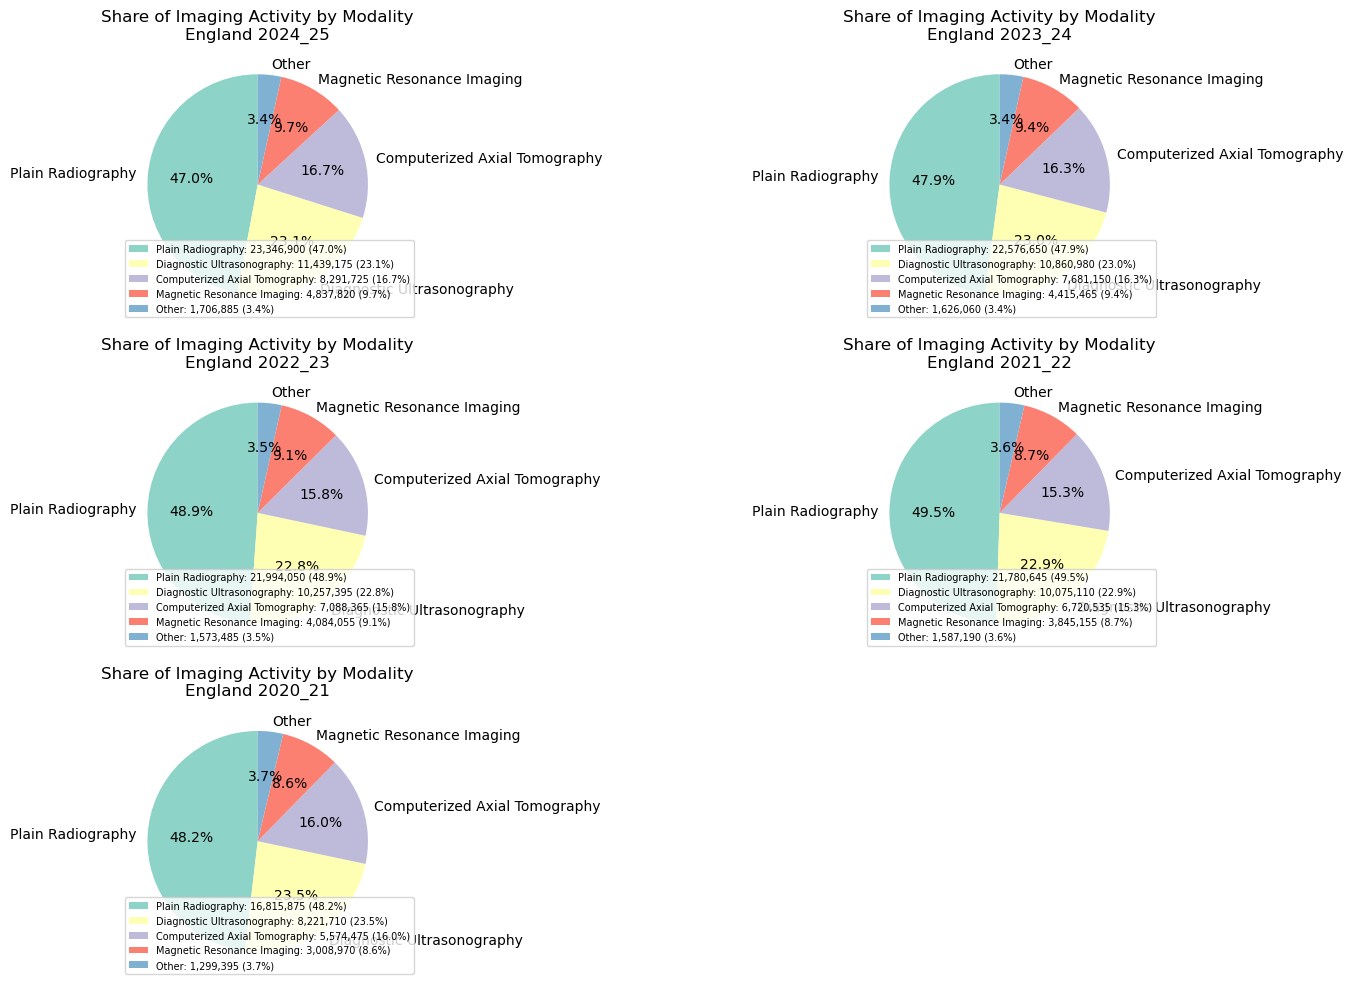

In [10]:
# Function to process one year
def process_year(df):
    # Keep only the England row
    eng = df[df["Provider name"].str.upper() == "ENGLAND"].copy()
    
    # Ensure numeric
    eng["Year"] = pd.to_numeric(eng["Year"], errors="coerce")
    
    # Sort by volume
    eng = eng.sort_values("Year", ascending=False)
    
    # Group smallest 5 into 'Other'
    top_mods = eng.iloc[:-5]
    other_sum = eng.iloc[-5:]["Year"].sum()
    
    # Build final df
    final_df = pd.concat([
        top_mods,
        pd.DataFrame({"Modality": ["Other"], "Year": [other_sum]})
    ], ignore_index=True)
    
    return final_df

# Create pie charts
plt.figure(figsize=(15, 10))

for i, (year, df) in enumerate(modality_dfs.items(), 1):
    final_df = process_year(df)
    
    # Legend labels
    total = final_df["Year"].sum()
    legend_labels = [
        f"{row.Modality}: {int(row['Year']):,} ({row['Year']/total:.1%})"
        for _, row in final_df.iterrows()
    ]
    
    plt.subplot(3, 2, i)  # grid: 3 rows, 2 columns
    wedges, texts, autotexts = plt.pie(
        final_df["Year"],
        labels=final_df["Modality"],
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3.colors
    )
    plt.title(f"Share of Imaging Activity by Modality\nEngland {year}")
    plt.legend(wedges, legend_labels, loc="best", fontsize=7)

plt.tight_layout()
plt.show()

# Count of Imaging Activity by Body Site

In [12]:
# Load Excel file and correct header
file_path = "Table-4-2024-25-Bodysite-Provider-Counts-2025-07-24-XLSX-219KB.xlsx"
body_df_24_25 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

# Load Excel file and correct header
file_path = "DID-Table-4-2023-24-Bodysite-Provider-Counts-xlsx-222KB (1).xlsx"
body_df_23_24 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

# Load Excel file and correct header
file_path = "Table-4-2022-23-Bodysite-Provider-Counts-XLSX-224KB.xlsx"
body_df_22_23 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

# Load Excel file and correct header
file_path = "Table-4-2021-22-Bodysite-Provider-Counts-2022-12-15-xlsx-223KB (2).xlsx"
body_df_21_22 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

# Load Excel file and correct header
file_path = "DID-Table-4-2020-21-Bodysite-Provider-Counts-xlsx-210KB.xlsx"
body_df_20_21 = pd.read_excel(file_path, sheet_name='Provider', skiprows=12)

In [13]:
body_df_24_25.head()
body_df_23_24.head()
body_df_22_23.head()
body_df_21_22.head()
body_df_20_21.head()

,Unnamed: 0,Region,Org Code,Provider name,Test,Source setting,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Jan,Feb,Mar,Year
0,NaN,-,-,ENGLAND,Abdomen and/or pelvis (Ultrasound),All,27175,44415,69590,86080,82430,92855,96775,93030,85840,83980,85925,99290,947380
1,NaN,-,-,ENGLAND,Abdomen and/or pelvis (Ultrasound),GP Direct Access,6500,12730,25565,34060,33710,39450,42565,41070,37300,37070,37580,43115,390705
2,NaN,-,-,ENGLAND,Brain (MRI),All,27270,39345,52415,61230,59730,62595,66035,64590,60870,61395,62235,72070,689780
3,NaN,-,-,ENGLAND,Brain (MRI),GP Direct Access,2510,3190,4460,5690,6285,6735,7365,7735,7555,7840,7505,8410,75280
4,NaN,-,-,ENGLAND,Chest (X-ray),All,427115,468880,509410,550470,523580,553990,597290,589535,609255,654700,583325,656145,6723690


In [14]:
body_df_24_25.info()
body_df_23_24.info()
body_df_22_23.info()
body_df_21_22.info()
body_df_20_21.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1585 entries, 0 to 1584
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      0 non-null      float64
 1   Region          1582 non-null   object 
 2   Org Code        1574 non-null   object 
 3   Provider name   1574 non-null   object 
 4   Test            1574 non-null   object 
 5   Source setting  1574 non-null   object 
 6   Apr             1425 non-null   object 
 7   May             1427 non-null   object 
 8   Jun             1432 non-null   object 
 9   Jul             1398 non-null   object 
 10  Aug             1368 non-null   object 
 11  Sep             1407 non-null   object 
 12  Oct             1423 non-null   object 
 13  Nov             1430 non-null   object 
 14  Dec             1430 non-null   object 
 15  Jan             1403 non-null   object 
 16  Feb             1420 non-null   object 
 17  Mar             1394 non-null   o

In [15]:
# Put all your dataframes into a dictionary
body_dfs = {
    "2024_25": body_df_24_25,
    "2023_24": body_df_23_24,
    "2022_23": body_df_22_23,
    "2021_22": body_df_21_22,
    "2020_21": body_df_20_21
}

# Drop the unnamed first column if present
for year, df in body_dfs.items():
    if df.columns[0].lower().startswith("unnamed"):
        df.drop(columns=df.columns[0], inplace=True)
    print(f"{year} -> columns after drop: {df.columns.tolist()}")


2024_25 -> columns after drop: ['Region', 'Org Code', 'Provider name', 'Test', 'Source setting', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']
2023_24 -> columns after drop: ['Region', 'Org Code', 'Provider name', 'Test', 'Source setting', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']
2022_23 -> columns after drop: ['Region', 'Org Code', 'Provider name', 'Test', 'Source setting', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']
2021_22 -> columns after drop: ['Region', 'Org Code', 'Provider name', 'Test', 'Source setting', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']
2020_21 -> columns after drop: ['Region', 'Org Code', 'Provider name', 'Test', 'Source setting', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Year']


In [16]:
# Get unique tests for each year
unique_tests_by_year = {}

for year, df in body_dfs.items():
    sorted_tests = sorted(df["Test"].dropna().unique())
    unique_tests_by_year[year] = sorted_tests
    print(f"{year} -> {len(sorted_tests)} unique tests: {sorted_tests}\n")

2024_25 -> 5 unique tests: ['Abdomen and/or pelvis (Ultrasound)', 'Brain (MRI)', 'Chest (X-ray)', 'Chest and/or abdomen (CT)', 'Kidney or Bladder (Ultrasound)']

2023_24 -> 5 unique tests: ['Abdomen and/or pelvis (Ultrasound)', 'Brain (MRI)', 'Chest (X-ray)', 'Chest and/or abdomen (CT)', 'Kidney or Bladder (Ultrasound)']

2022_23 -> 5 unique tests: ['Abdomen and/or pelvis (Ultrasound)', 'Brain (MRI)', 'Chest (X-ray)', 'Chest and/or abdomen (CT)', 'Kidney or Bladder (Ultrasound)']

2021_22 -> 5 unique tests: ['Abdomen and/or pelvis (Ultrasound)', 'Brain (MRI)', 'Chest (X-ray)', 'Chest and/or abdomen (CT)', 'Kidney or Bladder (Ultrasound)']

2020_21 -> 5 unique tests: ['Abdomen and/or pelvis (Ultrasound)', 'Brain (MRI)', 'Chest (X-ray)', 'Chest and/or abdomen (CT)', 'Kidney or Bladder (Ultrasound)']



In [17]:
# Quick counts per test for each year
test_counts_by_year = {}

for year, df in body_dfs.items():
    test_counts = df["Test"].value_counts(dropna=False).sort_values(ascending=False)
    test_counts_by_year[year] = test_counts
    print(f"=== {year} ===")
    print(test_counts, "\n")


=== 2024_25 ===
Test
Abdomen and/or pelvis (Ultrasound)    332
Chest (X-ray)                         325
Brain (MRI)                           323
Chest and/or abdomen (CT)             298
Kidney or Bladder (Ultrasound)        296
NaN                                    11
Name: count, dtype: int64 

=== 2023_24 ===
Test
Brain (MRI)                           330
Abdomen and/or pelvis (Ultrasound)    328
Chest (X-ray)                         322
Chest and/or abdomen (CT)             299
Kidney or Bladder (Ultrasound)        297
NaN                                    10
Name: count, dtype: int64 

=== 2022_23 ===
Test
Abdomen and/or pelvis (Ultrasound)    347
Brain (MRI)                           327
Chest (X-ray)                         326
Chest and/or abdomen (CT)             308
Kidney or Bladder (Ultrasound)        302
NaN                                    10
Name: count, dtype: int64 

=== 2021_22 ===
Test
Abdomen and/or pelvis (Ultrasound)    342
Brain (MRI)                       

In [18]:
# Count unique providers for each year
unique_providers_by_year = {}

for year, df in body_dfs.items():
    unique_count = df["Provider name"].nunique()
    unique_providers_by_year[year] = unique_count
    print(f"{year} -> Number of unique providers: {unique_count}")


2024_25 -> Number of unique providers: 160
2023_24 -> Number of unique providers: 160
2022_23 -> Number of unique providers: 165
2021_22 -> Number of unique providers: 167
2020_21 -> Number of unique providers: 164


In [19]:
# Ensure "Year" column is numeric for all years
for year, df in body_dfs.items():
    if "Year" in df.columns:
        df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
        print(f"{year} -> 'Year' column converted to numeric")
    else:
        print(f"{year} -> No 'Year' column found")


2024_25 -> 'Year' column converted to numeric
2023_24 -> 'Year' column converted to numeric
2022_23 -> 'Year' column converted to numeric
2021_22 -> 'Year' column converted to numeric
2020_21 -> 'Year' column converted to numeric


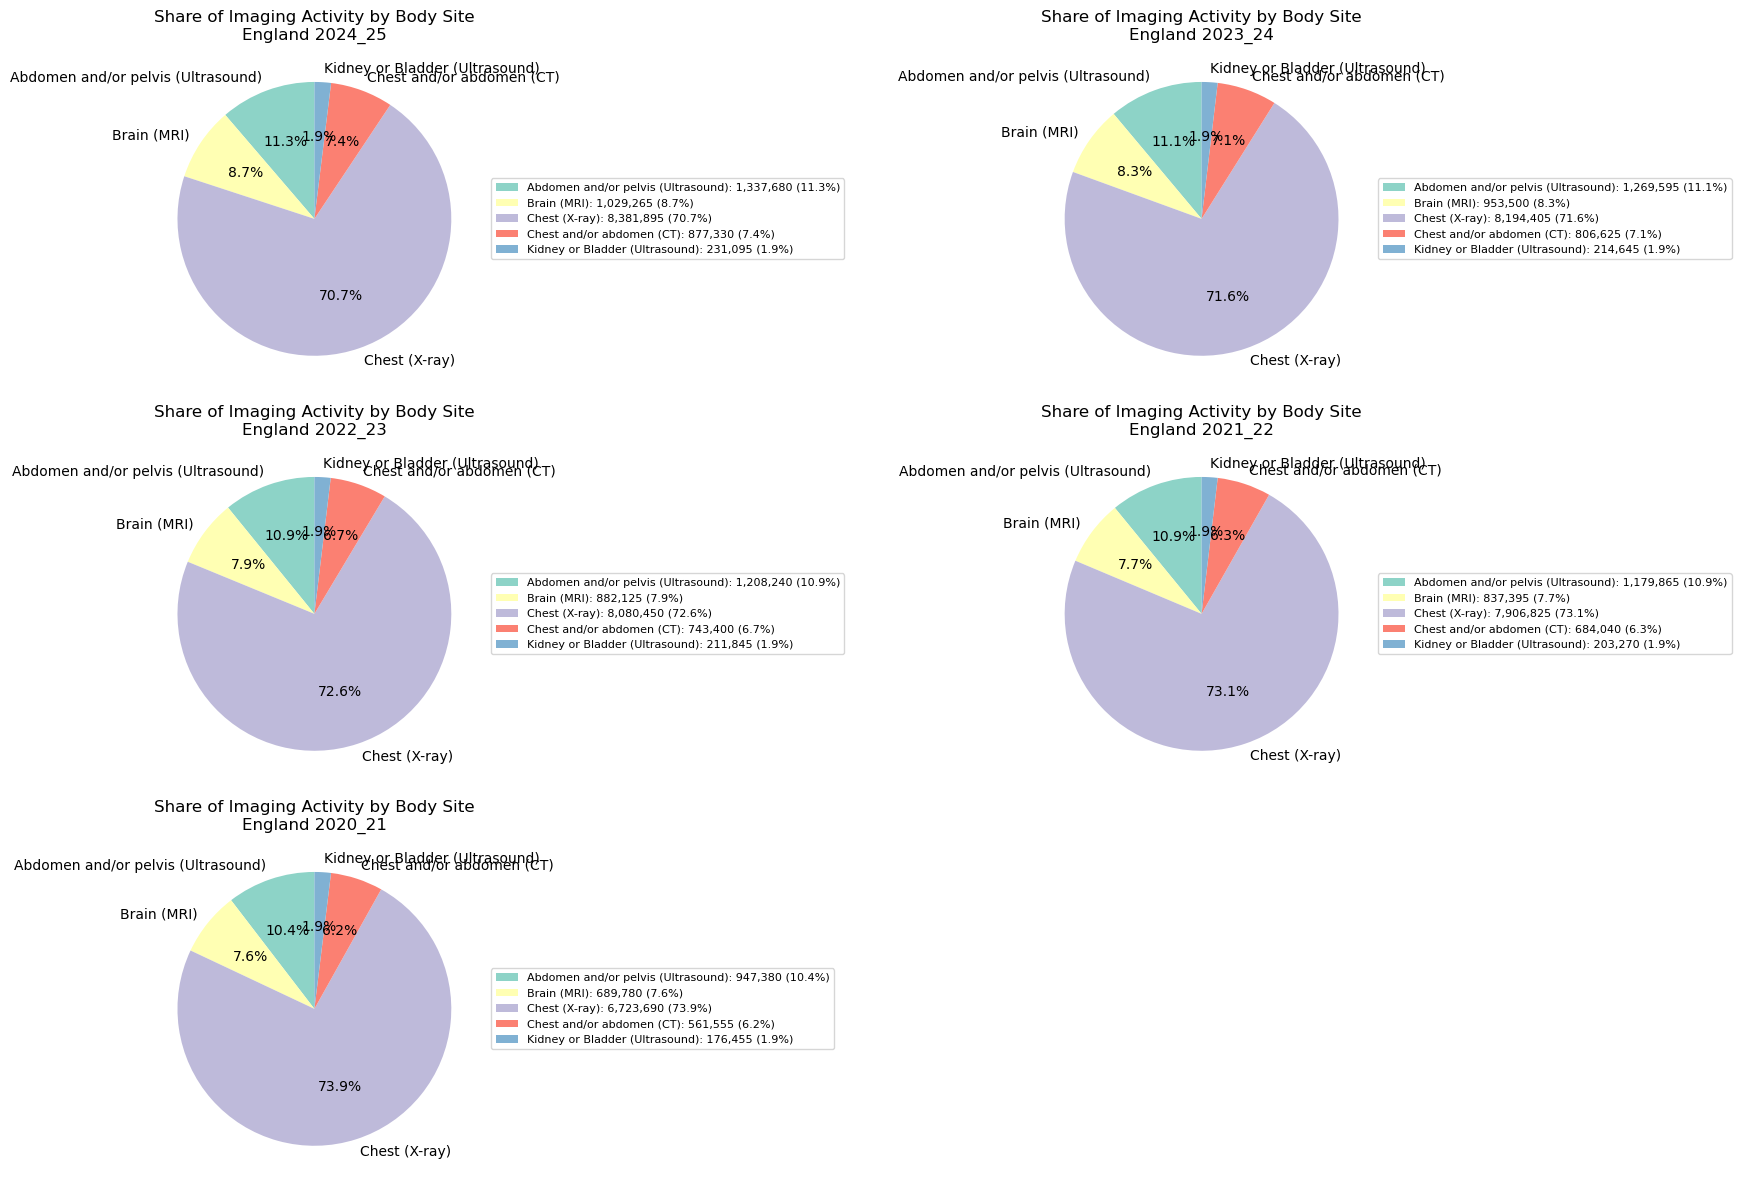

In [20]:
# Function to create body site summary for one year
def process_body_year(df):
    # Keep only England row
    body_summary = df[df["Provider name"].str.upper() == "ENGLAND"].copy()
    
    # Keep only Source setting == "All" if present
    if "Source setting" in body_summary.columns:
        body_summary = body_summary[body_summary["Source setting"].eq("All")]
    
    # Ensure numeric "Year" column
    if "Year" in body_summary.columns:
        body_summary["Year"] = pd.to_numeric(body_summary["Year"], errors="coerce")
    
    return body_summary

# Plot pie charts for all years
plt.figure(figsize=(18, 12))

for i, (year, df) in enumerate(body_dfs.items(), 1):
    summary = process_body_year(df)
    
    if summary.empty or "Year" not in summary.columns:
        continue
    
    total_scans = summary["Year"].sum()
    legend_labels = [
        f"{row.Test}: {int(row['Year']):,} ({row['Year']/total_scans:.1%})"
        for _, row in summary.iterrows()
    ]
    
    plt.subplot(3, 2, i)  # 3 rows, 2 columns grid
    wedges, texts, autotexts = plt.pie(
        summary["Year"],
        labels=summary["Test"],
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3.colors
    )
    plt.title(f"Share of Imaging Activity by Body Site\nEngland {year}")
    plt.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
# Filter all dataframes to Brain (MRI) and Source setting == "All"
for year, df in body_dfs.items():
    if "Test" in df.columns and "Source setting" in df.columns:
        body_dfs[year] = df[df["Test"].eq("Brain (MRI)") & df["Source setting"].eq("All")].copy()


In [22]:
# Convert "Year" to numeric and store as "Total" for all years
for year, df in body_dfs.items():
    if "Year" in df.columns:
        df["Total"] = pd.to_numeric(df["Year"], errors="coerce")
        body_dfs[year] = df  # Update the dictionary

In [23]:
# Create pivot tables for each year
pivot_body_dfs = {}

for year, df in body_dfs.items():
    if "Provider name" in df.columns and "Test" in df.columns and "Total" in df.columns:
        pivot_df = df.pivot_table(
            index='Provider name',
            columns='Test',
            values='Total',
            aggfunc='sum'
        ).fillna(0)
        pivot_body_dfs[year] = pivot_df

In [24]:
# Drop the national total row for all pivot tables
for year, df in pivot_body_dfs.items():
    pivot_body_dfs[year] = df.drop(index="ENGLAND", errors="ignore")

In [25]:
# Filter providers with 0 Brain (MRI) scans for all years
for year, df in pivot_body_dfs.items():
    zero_scan_df = df[df['Brain (MRI)'] == 0]
    
    print(f"\nYear: {year}")
    print(zero_scan_df)
    
    num_zero_scan_providers = zero_scan_df.shape[0]
    print(f"Number of providers with 0 Brain (MRI) scans: {num_zero_scan_providers}")


Year: 2024_25
Test                                    Brain (MRI)
Provider name                                      
Liverpool Women's NHS Foundation Trust          0.0
Tyneside Surgical Services Ltd                  0.0
Number of providers with 0 Brain (MRI) scans: 2

Year: 2023_24
Empty DataFrame
Columns: [Brain (MRI)]
Index: []
Number of providers with 0 Brain (MRI) scans: 0

Year: 2022_23
Test                                    Brain (MRI)
Provider name                                      
Liverpool Women's NHS Foundation Trust          0.0
Tyneside Surgical Services Ltd                  0.0
Number of providers with 0 Brain (MRI) scans: 2

Year: 2021_22
Empty DataFrame
Columns: [Brain (MRI)]
Index: []
Number of providers with 0 Brain (MRI) scans: 0

Year: 2020_21
Empty DataFrame
Columns: [Brain (MRI)]
Index: []
Number of providers with 0 Brain (MRI) scans: 0


In [26]:
# Drop rows with 0 Brain (MRI) scans for all years
for year, df in pivot_body_dfs.items():
    pivot_body_dfs[year] = df[df['Brain (MRI)'] > 0].copy()

In [27]:
for year, df in pivot_body_dfs.items():
    print(f"\nPivot table for {year}:")
    print(df.head())


Pivot table for 2024_25:
Test                                                Brain (MRI)
Provider name                                                  
Airedale NHS Foundation Trust                            1410.0
Alder Hey Children's NHS Foundation Trust                2290.0
Alliance Medical                                        15170.0
Ashford and St Peter's Hospitals NHS Foundation...       4345.0
Barking, Havering and Redbridge University Hosp...      12775.0

Pivot table for 2023_24:
Test                                                Brain (MRI)
Provider name                                                  
Airedale NHS Foundation Trust                            1500.0
Alder Hey Children's NHS Foundation Trust                1895.0
Alliance Medical                                        17275.0
Ashford and St Peter's Hospitals NHS Foundation...       4405.0
Barking, Havering and Redbridge University Hosp...      10615.0

Pivot table for 2022_23:
Test                      

In [28]:
for year, df in pivot_body_dfs.items():
    print(f"\nPivot table info for {year}:")
    print(df.info())


Pivot table info for 2024_25:
<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, Airedale NHS Foundation Trust to York and Scarborough Teaching Hospitals NHS Foundation Trust
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Brain (MRI)  145 non-null    float64
dtypes: float64(1)
memory usage: 2.3+ KB
None

Pivot table info for 2023_24:
<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, Airedale NHS Foundation Trust to York and Scarborough Teaching Hospitals NHS Foundation Trust
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Brain (MRI)  150 non-null    float64
dtypes: float64(1)
memory usage: 6.4+ KB
None

Pivot table info for 2022_23:
<class 'pandas.core.frame.DataFrame'>
Index: 151 entries, Airedale NHS Foundation Trust to York and Scarborough Teaching Hospitals NHS Foundation Trust
Data columns (total 1 columns):
 #   Column

In [29]:
for year, df in pivot_body_dfs.items():
    unique_count = df.index.nunique()
    print(f"Number of unique providers in {year}: {unique_count}")

Number of unique providers in 2024_25: 145
Number of unique providers in 2023_24: 150
Number of unique providers in 2022_23: 151
Number of unique providers in 2021_22: 154
Number of unique providers in 2020_21: 155


In [30]:
# Combine all years into one DataFrame for Excel export
combined_brain_scans = []

for year, df in pivot_body_dfs.items():
    # Copy the DataFrame to avoid modifying original
    df_copy = df.copy()
    
    # Add Year column (make it readable, e.g., 2024-25)
    df_copy['Year'] = year.replace('_', '-')
    
    # Reset index to make Provider name a column
    df_copy = df_copy.reset_index()
    
    # Keep only relevant columns
    df_copy = df_copy[['Year', 'Provider name', 'Brain (MRI)']]
    
    combined_brain_scans.append(df_copy)

# Concatenate all years
combined_brain_scans_df = pd.concat(combined_brain_scans, ignore_index=True)

# Export to Excel
output_path = "Provider_Scans_5_years.xlsx"
combined_brain_scans_df.to_excel(output_path, sheet_name="MRI (Brain)", index=False)

print(f"Excel file saved: {output_path}")

Excel file saved: Provider_Scans_5_years.xlsx


# MRI (Brain) Percentage to MRI¶

In [32]:
rows = []  # collect table rows here
brain_mri_pct_lookup = {}

for year in modality_dfs.keys():
    modality_df = modality_dfs[year]
    body_df = body_dfs[year]
    
    try:
        mri_total = modality_df[
            (modality_df["Provider name"].str.upper() == "ENGLAND") &
            (modality_df["Modality"] == "Magnetic Resonance Imaging")
        ]["Year"].iloc[0]
    except (IndexError, KeyError):
        mri_total = 0
    
    try:
        brain_mri_total = body_df[
            (body_df["Provider name"].str.upper() == "ENGLAND") &
            (body_df["Test"] == "Brain (MRI)")
        ]["Year"].iloc[0]
    except (IndexError, KeyError):
        brain_mri_total = 0

    brain_mri_pct = (brain_mri_total / mri_total * 100) if mri_total else 0

    # Store as decimal (e.g., 0.213 instead of 21.3)
    brain_mri_pct_lookup[year] = brain_mri_pct / 100  # convert from % to decimal

    # add row for table
    rows.append([year, brain_mri_total, mri_total, brain_mri_pct])

# make a DataFrame after loop
table_df = pd.DataFrame(rows, columns=["Year", "Brain MRI", "Total MRI", "Brain MRI %"])

# pretty print
print("\nSummary Table:")
print(table_df.to_string(index=False, formatters={
    "Brain MRI": "{:,}".format,
    "Total MRI": "{:,}".format,
    "Brain MRI %": "{:.1f}%".format
}))


Summary Table:
   Year   Brain MRI Total MRI Brain MRI %
2024_25 1,029,265.0 4,837,820       21.3%
2023_24   953,500.0 4,415,465       21.6%
2022_23   882,125.0 4,084,055       21.6%
2021_22   837,395.0 3,845,155       21.8%
2020_21   689,780.0 3,008,970       22.9%


# Provider-level Diagnostic Waiting Time Analysis

In [34]:
pip install xlrd

In [35]:
# 2024-25
file_path_24_25 = 'Monthly-Diagnostics-Web-File-Provider-March-2025_SW40K.xls'
dwta_df_24_25 = pd.read_excel(file_path_24_25, sheet_name='Provider by Test', engine='xlrd', skiprows=13)

# 2023-24
file_path_23_24 = 'Monthly-Diagnostics-Web-File-Provider-March-2024.xls'
dwta_df_23_24 = pd.read_excel(file_path_23_24, sheet_name='Provider by Test', engine='xlrd', skiprows=13)

# 2022-23
file_path_22_23 = 'Monthly-Diagnostics-Web-File-Provider-March-2023_OLEX2.xls'
dwta_df_22_23 = pd.read_excel(file_path_22_23, sheet_name='Provider by Test', engine='xlrd', skiprows=13)

# 2021-22
file_path_21_22 = 'Monthly-Diagnostics-Web-File-Provider-March-2022_C3L10.xls'
dwta_df_21_22 = pd.read_excel(file_path_21_22, sheet_name='Provider by Test', engine='xlrd', skiprows=13)

# 2020-21
file_path_20_21 = 'Monthly-Diagnostics-Web-File-Provider-March-2021-WT36C.xls'
dwta_df_20_21 = pd.read_excel(file_path_20_21, sheet_name='Provider by Test', engine='xlrd', skiprows=13)


In [36]:
dwta_df_24_25.info()
dwta_df_23_24.info()
dwta_df_22_23.info()
dwta_df_21_22.info()
dwta_df_20_21.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3185 entries, 0 to 3184
Data columns (total 30 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Unnamed: 0                                           0 non-null      float64
 1   Regional Team Code                                   3183 non-null   object 
 2   Regional Team Name                                   3183 non-null   object 
 3   Provider Code                                        3183 non-null   object 
 4   Provider Name                                        3184 non-null   object 
 5   Diagnostic ID                                        3183 non-null   float64
 6   Diagnostic Test Name                                 3183 non-null   object 
 7   Total Waiting List                                   3184 non-null   float64
 8   Number waiting 6+ Weeks                              3184 non-null  

In [37]:
# List of your DWTA datasets and corresponding year labels
dwta_dfs = [
    (dwta_df_24_25, "2024/25"),
    (dwta_df_23_24, "2023/24"),
    (dwta_df_22_23, "2022/23"),
    (dwta_df_21_22, "2021/22"),
    (dwta_df_20_21, "2020/21"),
]

for df, year_label in dwta_dfs:
    # Step 1: Remove 'Total' row if it exists
    filtered_df = df[~df['Diagnostic Test Name'].eq('Total')]

    # Step 2: Group by test and sum waiting totals
    grouped = filtered_df.groupby('Diagnostic Test Name')['Total Waiting List'].sum()

    # Step 3: Sort and group lowest 8 into 'Other'
    sorted_grouped = grouped.sort_values()
    smallest = sorted_grouped[:8]
    others_sum = smallest.sum()

    top_items = sorted_grouped[8:]
    grouped_final = top_items.copy()
    grouped_final['Other'] = others_sum

In [38]:
for df, year_label in dwta_dfs:
    total_providers = df['Provider Name'].nunique()
    print(f"Number of unique providers ({year_label}): {total_providers}")

Number of unique providers (2024/25): 433
Number of unique providers (2023/24): 425
Number of unique providers (2022/23): 406
Number of unique providers (2021/22): 399
Number of unique providers (2020/21): 386


In [39]:
# Filter for MRI only
for df, year_label in dwta_dfs:
    mri_df = df[
        (df['Diagnostic Test Name'] == 'Magnetic Resonance Imaging') &
        (df['Number waiting 6+ Weeks'] > 0)
    ]
    mri_providers = mri_df['Provider Name'].nunique()
    print(f"Number of providers with at least 1 MRI >6 weeks ({year_label}): {mri_providers}")

Number of providers with at least 1 MRI >6 weeks (2024/25): 205
Number of providers with at least 1 MRI >6 weeks (2023/24): 189
Number of providers with at least 1 MRI >6 weeks (2022/23): 172
Number of providers with at least 1 MRI >6 weeks (2021/22): 174
Number of providers with at least 1 MRI >6 weeks (2020/21): 183


In [40]:
from IPython.display import display

# === Step 0: Brain MRI % lookup table (from modality + body data analysis) ===
# Replace with your actual calculated values
brain_mri_pct_lookup = {
    "2024-25": 0.213,  # 21.3%
    "2023-24": 0.216,  # 21.6%
    "2022-23": 0.216,  # 21.6%
    "2021-22": 0.218,  # 21.8% (example – update with your real numbers)
    "2020-21": 0.219   # 21.9% (example – update with your real numbers)
}

# === Step 1: List of DWTA file paths ===
dwta_files = {
    "2024-25": 'Monthly-Diagnostics-Web-File-Provider-March-2025_SW40K.xls',
    "2023-24": 'Monthly-Diagnostics-Web-File-Provider-March-2024.xls',
    "2022-23": 'Monthly-Diagnostics-Web-File-Provider-March-2023_OLEX2.xls',
    "2021-22": 'Monthly-Diagnostics-Web-File-Provider-March-2022_C3L10.xls',
    "2020-21": 'Monthly-Diagnostics-Web-File-Provider-March-2021-WT36C.xls'
}

# Dictionary to store brain MRI summaries for each year
brain_mri_summaries = {}

for year, file_path in dwta_files.items():
    # === Step 2: Load Excel file ===
    df_raw = pd.read_excel(file_path, sheet_name="Provider by Test", engine="xlrd", skiprows=13)
    
    # === Step 3: Rename relevant columns ===
    df_raw = df_raw.rename(columns={
        "Provider Name": "Provider",
        "Diagnostic Test Name": "Test",
        "Total Waiting List": "Total Waiting",
        "Number waiting 6+ Weeks": "Waiting 6+ Weeks",
        "Percentage waiting 6+ weeks": "% Waiting 6+ Weeks"
    })
    
    # === Step 4: Filter for MRI only and valid providers ===
    df_mri = df_raw[df_raw["Test"] == "Magnetic Resonance Imaging"].copy()
    df_mri = df_mri[df_mri["Provider"].notna()]
    
    # === Step 5: Pivot tables ===
    wait_total = df_mri.pivot_table(index="Provider", values="Total Waiting", aggfunc="sum").fillna(0)
    wait_6plus = df_mri.pivot_table(index="Provider", values="Waiting 6+ Weeks", aggfunc="sum").fillna(0)
    wait_percent = df_mri.pivot_table(index="Provider", values="% Waiting 6+ Weeks", aggfunc="mean").fillna(0)
    
    # === Step 6: Apply correct Brain MRI % for this year ===
    pct = brain_mri_pct_lookup.get(year, 0)  # default 0 if missing
    
    wait_total['Brain MRI Waiting'] = wait_total["Total Waiting"] * pct
    wait_6plus['Brain MRI 6+ Week Wait'] = wait_6plus["Waiting 6+ Weeks"] * pct
    wait_percent['Brain MRI % 6+ Weeks'] = wait_percent["% Waiting 6+ Weeks"]
    
    # === Step 7: Combine into summary table ===
    brain_mri_waiting = (
        wait_total[["Brain MRI Waiting"]]
        .join(wait_6plus[["Brain MRI 6+ Week Wait"]])
        .join(wait_percent[["Brain MRI % 6+ Weeks"]])
    )
    
    # Store in dictionary
    brain_mri_summaries[year] = brain_mri_waiting

# === Step 8: Display brain MRI summary for each year ===
for year in ["2024-25","2023-24","2022-23","2021-22","2020-21"]:
    pct_used = brain_mri_pct_lookup.get(year, 0)
    print(f"=== {year} === (Brain MRI % used: {pct_used:.1%})")
    display(brain_mri_summaries[year].head())


=== 2024-25 === (Brain MRI % used: 21.3%)


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,138.876,2.343,0.016871
Alder Hey Children's NHS Foundation Trust,29.820,0.000,0.000000
Alexandra Hospital,0.639,0.000,0.000000
Alliance Medical MRI Service - Essex,15.762,0.000,0.000000
Ashford and St Peter's Hospitals NHS Foundation Trust,482.232,28.968,0.060071


=== 2023-24 === (Brain MRI % used: 21.6%)


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,146.448,8.856,0.060472
Alder Hey Children's NHS Foundation Trust,23.328,0.000,0.000000
Alexandra Hospital,1.512,0.216,0.142857
Alliance Medical MRI Service - Essex,0.000,0.000,0.000000
Ashford and St Peter's Hospitals NHS Foundation Trust,410.616,32.616,0.079432


=== 2022-23 === (Brain MRI % used: 21.6%)


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,154.440,6.048,0.039161
Alder Hey Children's NHS Foundation Trust,25.488,0.000,0.000000
Alexandra Hospital,1.512,0.000,0.000000
Alliance Medical MRI Service - Essex,0.000,0.000,0.000000
Ashford and St Peter's Hospitals NHS Foundation Trust,437.400,39.096,0.089383


=== 2021-22 === (Brain MRI % used: 21.8%)


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,114.886,5.450,0.047438
Alder Hey Children's NHS Foundation Trust,43.382,9.156,0.211055
Alexandra Hospital,6.976,0.000,0.000000
Alliance Medical MRI Service - Essex,0.000,0.000,0.000000
Ashford and St Peter's Hospitals NHS Foundation Trust,407.442,1.526,0.003745


=== 2020-21 === (Brain MRI % used: 21.9%)


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,76.431,0.000,0.000000
Alder Hey Children's NHS Foundation Trust,13.359,0.219,0.016393
Alliance Medical MRI Service - Essex,0.000,0.000,0.000000
Ashford and St Peter's Hospitals NHS Foundation Trust,200.166,0.219,0.001094
Ashtead Hospital,2.847,0.219,0.076923


In [41]:
# Iterate over each year
for year, brain_mri_waiting in brain_mri_summaries.items():
    # Filter providers with 0 patients waiting over 6 weeks
    zero_6wks_wait_df = brain_mri_waiting[brain_mri_waiting['Brain MRI 6+ Week Wait'] == 0]
    
    # Display results
    print(f"=== {year} - Providers with 0 patients waiting 6+ weeks ===")
    display(zero_6wks_wait_df)
    
    # Count number of efficient providers
    num_efficient_providers = zero_6wks_wait_df.shape[0]
    print(f"Number of providers with 0 6+ weeks waiters: {num_efficient_providers}\n")

=== 2024-25 - Providers with 0 patients waiting 6+ weeks ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Alder Hey Children's NHS Foundation Trust,29.820,0.0,0.0
Alexandra Hospital,0.639,0.0,0.0
Alliance Medical MRI Service - Essex,15.762,0.0,0.0
Ashtead Hospital,7.242,0.0,0.0
Barnsley Hospital NHS Foundation Trust,129.504,0.0,0.0
...,...,...,...
The Rotherham NHS Foundation Trust,158.472,0.0,0.0
The Royal Marsden NHS Foundation Trust,49.416,0.0,0.0
Three Shires Hospital,5.325,0.0,0.0


Number of providers with 0 6+ weeks waiters: 80

=== 2023-24 - Providers with 0 patients waiting 6+ weeks ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Alder Hey Children's NHS Foundation Trust,23.328,0.0,0.0
Alliance Medical MRI Service - Essex,0.000,0.0,0.0
Ashtead Hospital,4.104,0.0,0.0
Bath Clinic,3.240,0.0,0.0
Beacon Medical Services Group Limited,47.520,0.0,0.0
...,...,...,...
Winfield Hospital,0.216,0.0,0.0
Winterbourne Hospital,0.648,0.0,0.0
Woodland Hospital,0.648,0.0,0.0


Number of providers with 0 6+ weeks waiters: 86

=== 2022-23 - Providers with 0 patients waiting 6+ weeks ===


...

Number of providers with 0 6+ weeks waiters: 105

=== 2021-22 - Providers with 0 patients waiting 6+ weeks ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Alexandra Hospital,6.976,0.0,0.0
Alliance Medical MRI Service - Essex,0.000,0.0,0.0
Ashtead Hospital,0.218,0.0,0.0
Bath Clinic,7.848,0.0,0.0
Beacon Park Hospital,0.218,0.0,0.0
...,...,...,...
Winfield Hospital,0.000,0.0,0.0
Winterbourne Hospital,0.654,0.0,0.0
Woodland Hospital,3.052,0.0,0.0


Number of providers with 0 6+ weeks waiters: 97

=== 2020-21 - Providers with 0 patients waiting 6+ weeks ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,76.431,0.0,0.0
Alliance Medical MRI Service - Essex,0.000,0.0,0.0
BMI - Bath Clinic,0.657,0.0,0.0
BMI - Bishops Wood,2.628,0.0,0.0
BMI - Chelsfield Park Hospital,4.161,0.0,0.0
...,...,...,...
The Royal Marsden NHS Foundation Trust,0.000,0.0,0.0
The Yorkshire Clinic,0.438,0.0,0.0
Walsall Healthcare NHS Trust,286.233,0.0,0.0


Number of providers with 0 6+ weeks waiters: 92



In [42]:
# Filter all years to keep only providers with >0 patients waiting over 6 weeks
for year in brain_mri_summaries:
    brain_mri_summaries[year] = brain_mri_summaries[year][
        brain_mri_summaries[year]['Brain MRI 6+ Week Wait'] > 0
    ].copy()

# Display filtered summaries for all years
for year in brain_mri_summaries:
    print(f"\n=== {year} ===")
    display(brain_mri_summaries[year].head())


=== 2024-25 ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,138.876,2.343,0.016871
Ashford and St Peter's Hospitals NHS Foundation Trust,482.232,28.968,0.060071
"Barking, Havering and Redbridge University Hospitals NHS Trust",647.094,31.311,0.048387
Barts Health NHS Trust,1338.705,447.300,0.334129
Bedfordshire Hospitals NHS Foundation Trust,611.523,77.745,0.127133



=== 2023-24 ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,146.448,8.856,0.060472
Alexandra Hospital,1.512,0.216,0.142857
Ashford and St Peter's Hospitals NHS Foundation Trust,410.616,32.616,0.079432
"Barking, Havering and Redbridge University Hospitals NHS Trust",839.808,47.520,0.056584
Barnsley Hospital NHS Foundation Trust,96.984,2.376,0.024499



=== 2022-23 ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,154.440,6.048,0.039161
Ashford and St Peter's Hospitals NHS Foundation Trust,437.400,39.096,0.089383
"Barking, Havering and Redbridge University Hospitals NHS Trust",517.968,33.480,0.064637
Barnsley Hospital NHS Foundation Trust,80.568,3.456,0.042895
Barts Health NHS Trust,1472.904,465.912,0.316322



=== 2021-22 ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Airedale NHS Foundation Trust,114.886,5.450,0.047438
Alder Hey Children's NHS Foundation Trust,43.382,9.156,0.211055
Ashford and St Peter's Hospitals NHS Foundation Trust,407.442,1.526,0.003745
"Barking, Havering and Redbridge University Hospitals NHS Trust",504.234,245.032,0.485949
Barnsley Hospital NHS Foundation Trust,4.360,0.218,0.050000



=== 2020-21 ===


,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks
Provider,,,
Alder Hey Children's NHS Foundation Trust,13.359,0.219,0.016393
Ashford and St Peter's Hospitals NHS Foundation Trust,200.166,0.219,0.001094
Ashtead Hospital,2.847,0.219,0.076923
BMI - The Blackheath Hospital,5.475,0.219,0.040000
BMI - The London Independent Hospital,9.417,1.314,0.139535


In [43]:
# Dictionary to store unique provider-region pairs for each year
provider_regions_yearly = {}

for year, file_path in dwta_files.items():
    # Load the file
    df_raw = pd.read_excel(file_path, sheet_name="Provider by Test", engine="xlrd", skiprows=13)
    
    # Rename columns
    df_raw = df_raw.rename(columns={
        "Provider Name": "Provider",
        "Diagnostic Test Name": "Test",
        "Total Waiting List": "Total Waiting",
        "Number waiting 6+ Weeks": "Waiting 6+ Weeks",
        "Percentage waiting 6+ weeks": "% Waiting 6+ Weeks",
        "Regional Team Name": "Region"  # rename for consistency
    })
    
    # Filter for MRI and valid providers
    df_mri = df_raw[df_raw["Test"] == "Magnetic Resonance Imaging"].copy()
    df_mri = df_mri[df_mri["Provider"].notna()]
    
    # Keep only unique Provider-Region pairs
    provider_regions = df_mri[['Provider', 'Region']].drop_duplicates()
    
    # Store in dictionary
    provider_regions_yearly[year] = provider_regions

In [44]:
# Step 8: Add Regional Team Name for all years
for year in brain_mri_summaries:
    # Merge brain MRI summary with provider-region mapping
    brain_mri_summaries[year] = (
        brain_mri_summaries[year]
        .reset_index()
        .merge(provider_regions_yearly[year], on="Provider", how="left")
        .set_index("Provider")
    )

In [45]:
for year, df in brain_mri_summaries.items():
    print(f"\n=== {year} ===")
    df.info()


=== 2024-25 ===
<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, Airedale NHS Foundation Trust to York and Scarborough Teaching Hospitals NHS Foundation Trust
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Brain MRI Waiting       205 non-null    float64
 1   Brain MRI 6+ Week Wait  205 non-null    float64
 2   Brain MRI % 6+ Weeks    205 non-null    float64
 3   Region                  205 non-null    object 
dtypes: float64(3), object(1)
memory usage: 8.0+ KB

=== 2023-24 ===
<class 'pandas.core.frame.DataFrame'>
Index: 190 entries, Airedale NHS Foundation Trust to York and Scarborough Teaching Hospitals NHS Foundation Trust
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Brain MRI Waiting       190 non-null    float64
 1   Brain MRI 6+ Week Wait  190 non-null    float64
 2   Brain MRI %

In [46]:
# Combine all years into a single DataFrame
waiting_time_all_years = []

for year, df in brain_mri_summaries.items():
    temp = df.reset_index()  # Provider as a column
    temp['Year'] = year
    # Reorder columns
    temp = temp[['Year', 'Region', 'Provider', 'Brain MRI Waiting', 'Brain MRI 6+ Week Wait', 'Brain MRI % 6+ Weeks']]
    waiting_time_all_years.append(temp)

# Concatenate all years
waiting_time_df = pd.concat(waiting_time_all_years, ignore_index=True)

# === Write to new sheet in existing Excel file ===
output_file = "Provider_Scans_5_years.xlsx"

with pd.ExcelWriter(output_file, engine='openpyxl', mode='a') as writer:
    waiting_time_df.to_excel(writer, sheet_name="Waiting Time", index=False)

print(f"Waiting Time sheet successfully added to {output_file}")

Waiting Time sheet successfully added to Provider_Scans_5_years.xlsx


# Estimating Radiologist by Trust

In [48]:
# === Step 1: Load Workforce by Organisation (file 2) ===
file_org = "NHS Workforce Statistics, March 2025 England and Organisation.xlsx"
df_org_24_25 = pd.read_excel(file_org, sheet_name="3. NHSE, Org & SG - FTE", skiprows=5)

file_org = "NHS Workforce Statistics, March 2024 England and Organisation.xlsx"
df_org_23_24 = pd.read_excel(file_org, sheet_name="3. NHSE, Org & SG - FTE", skiprows=5)

file_org = "NHS Workforce Statistics, March 2023 England and Organisation.xlsx"
df_org_22_23 = pd.read_excel(file_org, sheet_name="3. NHSE, Org & SG - FTE", skiprows=5)

file_org = "NHS Workforce Statistics, March 2022 England and Organisation.xlsx"
df_org_21_22 = pd.read_excel(file_org, sheet_name="3. NHSE, Org & SG - FTE", skiprows=5)

file_org = "NHS Workforce Statistics, March 2021 England and Organisation.xlsx"
df_org_20_21 = pd.read_excel(file_org, sheet_name="3. NHSE, Org & SG - FTE", skiprows=6)

In [49]:
print("=== Workforce 2024-25 ===")
display(df_org_24_25.head())

print("\n=== Workforce 2023-24 ===")
display(df_org_23_24.head())

print("\n=== Workforce 2022-23 ===")
display(df_org_22_23.head())

print("\n=== Workforce 2021-22 ===")
display(df_org_21_22.head())

print("\n=== Workforce 2020-21 ===")
display(df_org_20_21.head())

=== Workforce 2024-25 ===


,NHS England region code,NHS England region name,ICS code,ICS name,Organisation name,Organisation code,Total,Professionally qualified clinical staff,HCHS Doctors,Consultant,...,Support to clinical staff,"Support to doctors, nurses & midwives",Support to ambulance staff,Support to ST&T staff,NHS infrastructure support,Senior managers,Managers,Central functions,"Hotel, property & estates",Unknown classification
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,England,NaN,NaN,NaN,NaN,1.375679e+06,741746.93749,148011.31854,59097.33454,...,413118.98223,297892.06958,26069.68777,89157.22488,220530.42957,13577.00932,26712.72086,112695.77446,67544.92493,282.36768
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Y56,London,NaN,NaN,NaN,NaN,2.420616e+05,141592.29188,30963.51182,12375.40495,...,63388.75196,45395.05594,3611.36532,14382.33070,36947.64236,2784.48466,6265.90007,19605.30662,8291.95101,132.87090
4,NaN,NaN,QKK,South East London,NaN,NaN,6.089546e+04,35763.19758,7382.11460,3094.21104,...,15295.10241,9366.89761,3320.51287,2607.69193,9792.63911,787.74565,1173.56707,5336.38792,2494.93847,44.51666



=== Workforce 2023-24 ===


,NHS England region code,NHS England region name,ICS code,ICS name,Organisation name,Organisation code,Total,Professionally qualified clinical staff,HCHS Doctors,Consultant,...,Support to clinical staff,"Support to doctors, nurses & midwives",Support to ambulance staff,Support to ST&T staff,NHS infrastructure support,Central functions,"Hotel, property & estates",Senior managers,Managers,Other staff or those with unknown classification
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,England,NaN,NaN,NaN,NaN,1.368034e+06,736388.39050,147217.54705,58381.69958,...,411235.89840,296512.03296,26798.13190,87925.73354,220071.74838,112510.75191,67058.80927,13553.33948,26948.84772,338.08019
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Y56,London,NaN,NaN,NaN,NaN,2.396934e+05,139821.84052,30739.22845,12239.95205,...,62971.15121,45329.79405,3632.54251,14008.81465,36753.92245,19205.28230,8051.63840,2662.08164,6834.92011,146.46841
4,NaN,NaN,QKK,South East London,NaN,NaN,6.048531e+04,35453.40559,7339.99223,3065.46751,...,15309.10228,9420.61886,3341.90941,2546.57401,9687.10648,4947.56083,2229.23784,701.64006,1808.66775,35.70000



=== Workforce 2022-23 ===


,NHS England region code,NHS England region name,ICS code,ICS name,Organisation name,Organisation code,Total,Professionally qualified clinical staff,HCHS Doctors,Consultant,...,Support to clinical staff,"Support to doctors, nurses & midwives",Support to ambulance staff,Support to ST&T staff,NHS infrastructure support,Central functions,"Hotel, property & estates",Senior managers,Managers,Other staff or those with unknown classification
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,England,NaN,NaN,NaN,NaN,1.328644e+06,702045.52739,139655.75845,56255.43448,...,408395.33332,298396.31285,26145.56203,83853.45844,217665.94394,112428.78856,65562.54671,13516.62908,26157.97959,537.30447
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Y56,London,NaN,NaN,NaN,NaN,2.303493e+05,132605.99230,29192.51467,11859.62856,...,61812.82057,45425.74379,3522.05752,12865.01926,35692.70482,19032.90219,7762.20198,2502.55843,6395.04222,237.80083
4,NaN,NaN,QKK,South East London,NaN,NaN,5.935497e+04,34449.79202,7252.96495,3016.87313,...,15204.31533,9679.76561,3172.94025,2351.60947,9658.57667,4958.11189,2230.16099,687.68791,1782.61588,42.28750



=== Workforce 2021-22 ===


,NHS England region code,NHS England region name,ICS code,ICS name,Organisation name,Organisation code,Total,Professionally qualified clinical staff,HCHS Doctors,Consultant,...,Support to clinical staff,"Support to doctors, nurses & midwives",Support to ambulance staff,Support to ST&T staff,NHS infrastructure support,Central functions,"Hotel, property & estates",Senior managers,Managers,Other staff or those with unknown classification
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,England,NaN,NaN,NaN,NaN,1.256841e+06,662582.71263,132869.28509,54312.09555,...,387211.75922,284856.64422,25059.10820,77296.00680,206527.71716,108393.80934,61459.25491,12839.64660,23835.00631,518.75815
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Y56,London,NaN,NaN,NaN,NaN,2.174984e+05,125721.31977,28238.75174,11448.10090,...,58737.07560,43478.66321,3380.90616,11877.50623,32879.21585,18449.71866,6341.41866,2417.94727,5670.13126,160.80750
4,NaN,NaN,QKK,South East London,NaN,NaN,5.721616e+04,33192.29174,7023.25125,2907.37026,...,14785.77546,9527.46806,3042.08006,2216.22734,9215.60464,5102.73583,2085.86777,671.59179,1355.40925,22.48750



=== Workforce 2020-21 ===


,NHS England region code,NHS England region name,Organisation name,Organisation code,Total,Professionally qualified clinical staff,HCHS Doctors,Consultant,Associate Specialist,Specialty Doctor,...,Support to clinical staff,"Support to doctors, nurses & midwives",Support to ambulance staff,Support to ST&T staff,NHS infrastructure support,Central functions,"Hotel, property & estates",Senior managers,Managers,Other staff or those with unknown classification
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,England,NaN,NaN,1.212478e+06,642560.24667,127958.97450,52652.38353,1812.00115,8179.58861,...,372688.25500,276256.47960,24540.29250,71891.48290,196730.48591,102039.71736,59688.05918,12290.65423,22712.05514,498.71380
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Y56,London,NaN,NaN,2.086457e+05,121960.54933,27391.07055,11061.54554,252.45221,1191.06232,...,56085.18320,42032.29638,3116.79513,10936.09169,30370.66413,16794.89732,6024.95025,2211.56184,5339.25472,229.34667
4,NaN,NaN,"Barking, Havering and Redbridge University Hos...",RF4,6.833778e+03,4106.98122,1041.08719,373.57003,9.60000,96.48000,...,2141.66364,1686.84814,0.00000,454.81550,585.13334,448.12000,35.21334,38.00000,63.80000,0.00000


In [50]:
print("=== Workforce 2024-25 ===")
df_org_24_25.info()

print("\n=== Workforce 2023-24 ===")
df_org_23_24.info()

print("\n=== Workforce 2022-23 ===")
df_org_22_23.info()

print("\n=== Workforce 2021-22 ===")
df_org_21_22.info()

print("\n=== Workforce 2020-21 ===")
df_org_20_21.info()

=== Workforce 2024-25 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 33 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   NHS England region code                     18 non-null     object 
 1   NHS England region name                     8 non-null      object 
 2   ICS code                                    42 non-null     object 
 3   ICS name                                    42 non-null     object 
 4   Organisation name                           247 non-null    object 
 5   Organisation code                           247 non-null    object 
 6   Total                                       297 non-null    float64
 7   Professionally qualified clinical staff     297 non-null    float64
 8   HCHS Doctors                                297 non-null    float64
 9   Consultant                                  297 non-null    f

In [51]:
# count the provider name

print("=== 2024-25 ===")
print(f"Number of unique providers: {df_org_24_25['Organisation name'].nunique()}")

print("\n=== 2023-24 ===")
print(f"Number of unique providers: {df_org_23_24['Organisation name'].nunique()}")

print("\n=== 2022-23 ===")
print(f"Number of unique providers: {df_org_22_23['Organisation name'].nunique()}")

print("\n=== 2021-22 ===")
print(f"Number of unique providers: {df_org_21_22['Organisation name'].nunique()}")

print("\n=== 2020-21 ===")
print(f"Number of unique providers: {df_org_20_21['Organisation name'].nunique()}")


=== 2024-25 ===
Number of unique providers: 247

=== 2023-24 ===
Number of unique providers: 248

=== 2022-23 ===
Number of unique providers: 252

=== 2021-22 ===
Number of unique providers: 254

=== 2020-21 ===
Number of unique providers: 305


In [52]:
# Dictionary of all yearly DataFrames
org_years = {
    "2024-25": df_org_24_25,
    "2023-24": df_org_23_24,
    "2022-23": df_org_22_23,
    "2021-22": df_org_21_22,
    "2020-21": df_org_20_21
}

# Total radiologists per year
total_radiologists_yearly = {
    "2024-25": 5845,
    "2023-24": 5628,
    "2022-23": 5350,
    "2021-22": 5081,
    "2020-21": 4817
}

# Process each year's data
for year, df in org_years.items():
    # Remove ICBs
    df = df[~df['Organisation name'].str.contains("ICB", case=False, na=False)]
    
    # Forward-fill region info safely
    df = df.copy()  # avoid SettingWithCopyWarning
    df['NHS England region name'] = df['NHS England region name'].ffill()
    
    # Keep only necessary columns
    df = df[['NHS England region name', 'Organisation name', 'HCHS Doctors']]
    df = df.dropna(subset=['Organisation name'])
    
    # Convert doctors to numeric
    df['HCHS Doctors'] = pd.to_numeric(df['HCHS Doctors'], errors='coerce')
    
    # Estimate radiologists for this year
    total_nhs_doctors = df['HCHS Doctors'].sum()
    total_radiologists = total_radiologists_yearly[year]
    df['Estimated Radiologists'] = (df['HCHS Doctors'] / total_nhs_doctors) * total_radiologists
    
    # Sort by Estimated Radiologists
    df_sorted = df.sort_values(by='Estimated Radiologists', ascending=False)
    
    # Save back to the dictionary
    org_years[year] = df_sorted

In [53]:
# View top 10 organisations by estimated radiologists for each year
for year, df in org_years.items():
    print(f"\n=== Top 10 Estimated Radiologists: {year} ===")
    print(df.sort_values(by='Estimated Radiologists', ascending=False).head(10))


=== Top 10 Estimated Radiologists: 2024-25 ===
      NHS England region name  \
236                North West   
5                      London   
14                     London   
137                  Midlands   
25                     London   
300  North East and Yorkshire   
6                      London   
152                  Midlands   
171                  Midlands   
102                South East   

                                     Organisation name  HCHS Doctors  \
236         Manchester University NHS Foundation Trust    3616.72882   
5            Guy's and St Thomas' NHS Foundation Trust    3093.35670   
14                              Barts Health NHS Trust    3077.52255   
137  University Hospitals Birmingham NHS Foundation...    3065.27879   
25              Royal Free London NHS Foundation Trust    2563.84424   
300                 Leeds Teaching Hospitals NHS Trust    2516.58566   
6         King's College Hospital NHS Foundation Trust    2481.68210   
152        U

In [54]:
# Check providers with 0 estimated radiologists for each year
for year, df in org_years.items():
    zero_workforce_df = df[df['Estimated Radiologists'] == 0]
    
    print(f"\n=== Providers with 0 Estimated Radiologists: {year} ===")
    print(zero_workforce_df)
    
    num_zero_workforce_providers = zero_workforce_df.shape[0]
    print(f"Number of providers with 0 Estimated Radiologists: {num_zero_workforce_providers}")


=== Providers with 0 Estimated Radiologists: 2024-25 ===
    NHS England region name                          Organisation name  \
169                Midlands  East Midlands Ambulance Service NHS Trust   

     HCHS Doctors  Estimated Radiologists  
169           0.0                     0.0  
Number of providers with 0 Estimated Radiologists: 1

=== Providers with 0 Estimated Radiologists: 2023-24 ===
    NHS England region name                          Organisation name  \
170                Midlands  East Midlands Ambulance Service NHS Trust   

     HCHS Doctors  Estimated Radiologists  
170           0.0                     0.0  
Number of providers with 0 Estimated Radiologists: 1

=== Providers with 0 Estimated Radiologists: 2022-23 ===
    NHS England region name                          Organisation name  \
173                Midlands  East Midlands Ambulance Service NHS Trust   

     HCHS Doctors  Estimated Radiologists  
173           0.0                     0.0  
Number of

In [55]:
# Remove rows with 0 Estimated Radiologists for each year
for year, df in org_years.items():
    org_years[year] = df[df['Estimated Radiologists'] > 0].copy()

In [56]:
for year, df in org_years.items():
    print(f"\n=== {year} ===")
    df.info()


=== 2024-25 ===
<class 'pandas.core.frame.DataFrame'>
Index: 204 entries, 236 to 280
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NHS England region name  204 non-null    object 
 1   Organisation name        204 non-null    object 
 2   HCHS Doctors             204 non-null    float64
 3   Estimated Radiologists   204 non-null    float64
dtypes: float64(2), object(2)
memory usage: 8.0+ KB

=== 2023-24 ===
<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 237 to 220
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NHS England region name  205 non-null    object 
 1   Organisation name        205 non-null    object 
 2   HCHS Doctors             205 non-null    float64
 3   Estimated Radiologists   205 non-null    float64
dtypes: float64(2), object(2)
memory usage: 8.0+ KB

=== 2022-23

In [57]:
# Dictionary to store region summaries per year
region_summary_years = {}

for year, df in org_years.items():
    # Remove rows with 0 radiologists
    df = df[df['Estimated Radiologists'] > 0].copy()
    
    # Group by region and sum estimated radiologists
    region_radiologists = df.groupby('NHS England region name')['Estimated Radiologists'].sum().sort_values(ascending=False)
    
    # Convert to DataFrame
    region_radiologists_df = region_radiologists.reset_index()
    region_radiologists_df.columns = ['Region', 'Estimated Radiologists']
    
    # Save for later
    region_summary_years[year] = region_radiologists_df

 # Print the result for this year
    print(f"\n=== Region summary for {year} ===")
    print(region_radiologists_df)


=== Region summary for 2024-25 ===
                     Region  Estimated Radiologists
0                    London             1223.319075
1                  Midlands             1028.514437
2  North East and Yorkshire              870.615663
3                South East              806.234370
4                North West              796.624963
5           East of England              579.605173
6                South West              540.086319

=== Region summary for 2023-24 ===
                     Region  Estimated Radiologists
0                    London             1175.657175
1                  Midlands              990.065098
2  North East and Yorkshire              844.740151
3                South East              776.197543
4                North West              762.106683
5           East of England              558.851120
6                South West              520.382230

=== Region summary for 2022-23 ===
                     Region  Estimated Radiologists
0       

In [58]:
# List to collect yearly DataFrames
all_years_df_list = []

for year, df in org_years.items():
    # Remove rows with 0 radiologists
    df_copy = df[df['Estimated Radiologists'] > 0].copy()
    
    # Add a Year column
    df_copy['Year'] = year
    
    # Reorder columns to have Year first
    cols = ['Year'] + [col for col in df_copy.columns if col != 'Year']
    df_copy = df_copy[cols]
    
    # Append to the list
    all_years_df_list.append(df_copy)

# Concatenate all years
all_years_df = pd.concat(all_years_df_list, ignore_index=True)

# === Write to new sheet in existing Excel file ===
output_file = "Provider_Scans_5_years.xlsx"

with pd.ExcelWriter(output_file, engine='openpyxl', mode='a') as writer:
    all_years_df.to_excel(writer, sheet_name="Radiologist", index=False)

print(f"Radiologist sheet successfully added to {output_file}")

Radiologist sheet successfully added to Provider_Scans_5_years.xlsx


# Scan per Radiologist

In [60]:
# Load both sheets
scan = pd.read_excel("Provider_Scans_5_years.xlsx", sheet_name="MRI (Brain)")
radiologist = pd.read_excel("Provider_Scans_5_years.xlsx", sheet_name="Radiologist")

# Rename columns for consistency
scan = scan.rename(columns={"Provider name": "Provider"})
radiologist = radiologist.rename(columns={"Organisation name": "Provider"})

# === Clean provider names in both tables ===
def clean_provider(name):
    if pd.isnull(name):
        return ""
    name = str(name)
    name = re.sub(r'^\s*The\s+', '', name, flags=re.IGNORECASE)  # remove leading "The"
    name = re.sub(r'[,:-]', '', name)  # remove punctuation
    name = name.strip()
    return name

scan["Provider"] = scan["Provider"].apply(clean_provider)
radiologist["Provider"] = radiologist["Provider"].apply(clean_provider)

# === Merge on cleaned NHS Trust names ===
scan_radio = pd.merge(scan, radiologist, on=['Year', 'Provider'], how="inner")

# Clean and convert to numeric
scan_radio["Brain (MRI)"] = pd.to_numeric(scan_radio["Brain (MRI)"], errors='coerce')
scan_radio["Estimated Radiologists"] = pd.to_numeric(scan_radio["Estimated Radiologists"], errors='coerce')

# Drop rows where either is missing
scan_radio = scan_radio.dropna(subset=["Brain (MRI)", "Estimated Radiologists"])

# === Calculate Scan per Radiologist ===
scan_radio["Scans per Radiologist (Annual)"] = scan_radio["Brain (MRI)"] / scan_radio["Estimated Radiologists"]
scan_radio["Scans per Radiologist (Monthly)"] = scan_radio["Scans per Radiologist (Annual)"] / 12 # FTE
scan_radio["Scans per Radiologist (Daily)"] = scan_radio["Scans per Radiologist (Annual)"] / 253 # assuming working days each year = 253 days

# Preview
scan_radio.head()

,Year,Provider,Brain (MRI),NHS England region name,HCHS Doctors,Estimated Radiologists,Scans per Radiologist (Annual),Scans per Radiologist (Monthly),Scans per Radiologist (Daily)
0,2024-25,Airedale NHS Foundation Trust,1410,North East and Yorkshire,372.03789,14.724709,95.757408,7.979784,0.378488
1,2024-25,Alder Hey Children's NHS Foundation Trust,2290,North West,546.26475,21.620351,105.918726,8.826560,0.418651
2,2024-25,Barking Havering and Redbridge University Hosp...,12775,London,1328.98988,52.599454,242.873245,20.239437,0.959973
3,2024-25,Barnsley Hospital NHS Foundation Trust,2715,North East and Yorkshire,455.62170,18.032833,150.558706,12.546559,0.595094
4,2024-25,Barts Health NHS Trust,14190,London,3077.52255,121.803790,116.498838,9.708236,0.460470


In [61]:
scan_radio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659 entries, 0 to 658
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             659 non-null    object 
 1   Provider                         659 non-null    object 
 2   Brain (MRI)                      659 non-null    int64  
 3   NHS England region name          659 non-null    object 
 4   HCHS Doctors                     659 non-null    float64
 5   Estimated Radiologists           659 non-null    float64
 6   Scans per Radiologist (Annual)   659 non-null    float64
 7   Scans per Radiologist (Monthly)  659 non-null    float64
 8   Scans per Radiologist (Daily)    659 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 46.5+ KB


In [62]:
# Group by region and sum estimated radiologists
region_workload = scan_radio.groupby('NHS England region name')['Scans per Radiologist (Annual)'].sum().sort_values(ascending=False)

# Convert to DataFrame for display or plotting
region_workload_df = region_workload.reset_index()
region_workload_df.columns = ['Region', 'Scans per Radiologist (Annual)']

# View result
print(region_workload_df)

                     Region  Scans per Radiologist (Annual)
0                North West                    22579.420846
1                  Midlands                    19874.333375
2  North East and Yorkshire                    17096.615780
3                    London                    15689.069620
4                South East                    14652.695537
5           East of England                    10919.262640
6                South West                    10383.502031


In [63]:
print(scan_radio.columns)
print(waiting_time_df.columns)

Index(['Year', 'Provider', 'Brain (MRI)', 'NHS England region name',
       'HCHS Doctors', 'Estimated Radiologists',
       'Scans per Radiologist (Annual)', 'Scans per Radiologist (Monthly)',
       'Scans per Radiologist (Daily)'],
      dtype='object')
Index(['Year', 'Region', 'Provider', 'Brain MRI Waiting',
       'Brain MRI 6+ Week Wait', 'Brain MRI % 6+ Weeks'],
      dtype='object')


In [64]:
# Merge scan_radio with waiting_time_df on Year and Provider
scan_radio_merged = pd.merge(
    scan_radio,
    waiting_time_df,
    on=['Year', 'Provider'],   # merge on both
    how='left'
)

# Remove rows with at least one blank cell
scan_radio_merged = scan_radio_merged.dropna()

# Write to Excel (append sheet or replace if it exists)
with pd.ExcelWriter(
    "Provider_Scans_5_years.xlsx",
    mode='a',
    engine='openpyxl',
    if_sheet_exists='replace'   # replace the sheet if it already exists
) as writer:
    scan_radio_merged.to_excel(writer, sheet_name='Scans per Radiologist', index=False)

print("Scans per Radiologist sheet successfully updated (rows with blanks removed).")

Scans per Radiologist sheet successfully updated (rows with blanks removed).


# Scan-to-wait ratio

In [66]:
# Load both sheets
scan_df = pd.read_excel("Provider_Scans_5_years.xlsx", sheet_name="MRI (Brain)")
wait_df = pd.read_excel("Provider_Scans_5_years.xlsx", sheet_name="Waiting Time")

# Standardize key column name
scan_df = scan_df.rename(columns={"Provider name": "Provider"})
wait_df = wait_df.rename(columns={"Provider": "Provider"})

In [67]:
# clean NHS Trust
def clean_name(name):
    if pd.isnull(name): return ""
    name = re.sub(r'^\s*The\s+', '', name, flags=re.IGNORECASE)
    name = re.sub(r'[,:-]', '', name)
    return name.strip()

scan_df["Provider"] = scan_df["Provider"].apply(clean_name)
wait_df["Provider"] = wait_df["Provider"].apply(clean_name)

In [68]:
# merge
scan_wait = pd.merge(scan_df, wait_df, on=["Year", "Provider"], how="inner")

In [69]:
# Remove commas and convert to numeric
scan_wait["Brain (MRI)"] = pd.to_numeric(scan_wait["Brain (MRI)"], errors='coerce')
scan_wait["Brain MRI 6+ Week Wait"] = pd.to_numeric(scan_wait["Brain MRI 6+ Week Wait"], errors='coerce')

# drop rows where either column is NaN after conversion
scan_wait = scan_wait.dropna(subset=["Brain (MRI)", "Brain MRI 6+ Week Wait"])

In [70]:
# calculate scan-to-6+week-wait ratio
scan_wait = scan_wait[scan_wait['Brain MRI 6+ Week Wait'] > 0].copy() # only keep the trusts who has 6+ weeks waiting patients
scan_wait["Scan-to-6+Week-Wait Ratio"] = scan_wait["Brain (MRI)"] / scan_wait["Brain MRI 6+ Week Wait"]

In [71]:
scan_wait.head()

,Year,Provider,Brain (MRI),Region,Brain MRI Waiting,Brain MRI 6+ Week Wait,Brain MRI % 6+ Weeks,Scan-to-6+Week-Wait Ratio
0,2024-25,Airedale NHS Foundation Trust,1410,North East and Yorkshire Commissioning Region,138.876,2.343,0.016871,601.792574
1,2024-25,Ashford and St Peter's Hospitals NHS Foundatio...,4345,South East Commissioning Region,482.232,28.968,0.060071,149.993096
2,2024-25,Barking Havering and Redbridge University Hosp...,12775,London Commissioning Region,647.094,31.311,0.048387,408.003577
3,2024-25,Barts Health NHS Trust,14190,London Commissioning Region,1338.705,447.300,0.334129,31.723675
4,2024-25,Bedfordshire Hospitals NHS Foundation Trust,11370,East of England Commissioning Region,611.523,77.745,0.127133,146.247347


In [72]:
scan_wait.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       639 non-null    object 
 1   Provider                   639 non-null    object 
 2   Brain (MRI)                639 non-null    int64  
 3   Region                     639 non-null    object 
 4   Brain MRI Waiting          639 non-null    float64
 5   Brain MRI 6+ Week Wait     639 non-null    float64
 6   Brain MRI % 6+ Weeks       639 non-null    float64
 7   Scan-to-6+Week-Wait Ratio  639 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 40.1+ KB


In [73]:
# Write to Excel (append sheet or replace if it exists)
with pd.ExcelWriter(
    "Provider_Scans_5_years.xlsx",
    mode='a',
    engine='openpyxl',
    if_sheet_exists='replace'   # replace the sheet if it already exists
) as writer:
    scan_wait.to_excel(writer, sheet_name='Scan-to-wait ratio', index=False)

print("Scans to wait ratio sheet successfully updated.")

Scans to wait ratio sheet successfully updated.


# Demand Score (Low Efficiency + High Workload)

In [75]:
# Merge on Year and Provider
demand_df = pd.merge(
    scan_radio[["Year", "Provider", "Brain (MRI)", "Scans per Radiologist (Annual)"]],
    scan_wait[["Year", "Region", "Provider", "Scan-to-6+Week-Wait Ratio"]],
    on=["Year", "Provider"], 
    how="inner"
)

In [76]:
demand_df.head()

,Year,Provider,Brain (MRI),Scans per Radiologist (Annual),Region,Scan-to-6+Week-Wait Ratio
0,2024-25,Airedale NHS Foundation Trust,1410,95.757408,North East and Yorkshire Commissioning Region,601.792574
1,2024-25,Barking Havering and Redbridge University Hosp...,12775,242.873245,London Commissioning Region,408.003577
2,2024-25,Barts Health NHS Trust,14190,116.498838,London Commissioning Region,31.723675
3,2024-25,Bedfordshire Hospitals NHS Foundation Trust,11370,215.295058,East of England Commissioning Region,146.247347
4,2024-25,Birmingham Women's and Children's NHS Foundati...,4145,147.054510,Midlands Commissioning Region,353.819889


In [77]:
demand_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            600 non-null    object 
 1   Provider                        600 non-null    object 
 2   Brain (MRI)                     600 non-null    int64  
 3   Scans per Radiologist (Annual)  600 non-null    float64
 4   Region                          600 non-null    object 
 5   Scan-to-6+Week-Wait Ratio       600 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 28.3+ KB


In [78]:
# Normalize within each year: low efficiency = worse, high workload = worse
demand_df['Efficiency Rank'] = demand_df.groupby('Year')['Scan-to-6+Week-Wait Ratio'] \
                                        .rank(ascending=True)  

demand_df['Workload Rank'] = demand_df.groupby('Year')['Scans per Radiologist (Annual)'] \
                                      .rank(ascending=False)  

# Combine into a demand score (lower = worse = higher demand)
demand_df['Demand Score'] = demand_df['Efficiency Rank'] + demand_df['Workload Rank']

In [79]:
# Write to Excel (append sheet or replace if it exists)
with pd.ExcelWriter(
    "Provider_Scans_5_years.xlsx",
    mode='a',
    engine='openpyxl',
    if_sheet_exists='replace'   # replace the sheet if it already exists
) as writer:
    demand_df.to_excel(writer, sheet_name='Demand', index=False)

print("Demand sheet successfully updated.")

Demand sheet successfully updated.


# Final Trust-level Dataset

In [81]:
trust_df = pd.read_excel("Provider_Scans_5_years.xlsx", sheet_name="Demand")

In [82]:
trust_df.head()

,Year,Provider,Brain (MRI),Scans per Radiologist (Annual),Region,Scan-to-6+Week-Wait Ratio,Efficiency Rank,Workload Rank,Demand Score
0,2024-25,Airedale NHS Foundation Trust,1410,95.757408,North East and Yorkshire Commissioning Region,601.792574,87.0,110,197.0
1,2024-25,Barking Havering and Redbridge University Hosp...,12775,242.873245,London Commissioning Region,408.003577,79.0,18,97.0
2,2024-25,Barts Health NHS Trust,14190,116.498838,London Commissioning Region,31.723675,14.0,104,118.0
3,2024-25,Bedfordshire Hospitals NHS Foundation Trust,11370,215.295058,East of England Commissioning Region,146.247347,50.0,32,82.0
4,2024-25,Birmingham Women's and Children's NHS Foundati...,4145,147.054510,Midlands Commissioning Region,353.819889,72.0,84,156.0


In [83]:
trust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            600 non-null    object 
 1   Provider                        600 non-null    object 
 2   Brain (MRI)                     600 non-null    int64  
 3   Scans per Radiologist (Annual)  600 non-null    float64
 4   Region                          600 non-null    object 
 5   Scan-to-6+Week-Wait Ratio       600 non-null    float64
 6   Efficiency Rank                 600 non-null    float64
 7   Workload Rank                   600 non-null    int64  
 8   Demand Score                    600 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 42.3+ KB


In [84]:
trust_df.describe()

,Brain (MRI),Scans per Radiologist (Annual),Scan-to-6+Week-Wait Ratio,Efficiency Rank,Workload Rank,Demand Score
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,6440.816667,169.795024,1497.820009,60.550000,60.550000,121.100000
std,4950.217892,83.052013,4120.798463,34.754745,34.754769,42.438584
min,5.000000,0.733624,0.236206,1.000000,1.000000,10.000000
25%,3135.000000,129.858874,51.476424,30.750000,30.750000,90.750000
50%,5002.500000,165.988862,174.803182,60.500000,60.500000,118.000000
75%,8272.500000,203.858845,757.291066,90.250000,90.250000,152.000000
max,27325.000000,800.521150,41877.934272,124.000000,124.000000,232.000000


# Adoption Scenario Analysis

In [86]:
# Step 1: Load your Trust-level yearly data
trust_df = pd.read_excel("Provider_Scans_5_years.xlsx", sheet_name="Demand")
trust_df['Year'] = trust_df['Year'].astype(str)  # ensure year is string
trust_df.head()

,Year,Provider,Brain (MRI),Scans per Radiologist (Annual),Region,Scan-to-6+Week-Wait Ratio,Efficiency Rank,Workload Rank,Demand Score
0,2024-25,Airedale NHS Foundation Trust,1410,95.757408,North East and Yorkshire Commissioning Region,601.792574,87.0,110,197.0
1,2024-25,Barking Havering and Redbridge University Hosp...,12775,242.873245,London Commissioning Region,408.003577,79.0,18,97.0
2,2024-25,Barts Health NHS Trust,14190,116.498838,London Commissioning Region,31.723675,14.0,104,118.0
3,2024-25,Bedfordshire Hospitals NHS Foundation Trust,11370,215.295058,East of England Commissioning Region,146.247347,50.0,32,82.0
4,2024-25,Birmingham Women's and Children's NHS Foundati...,4145,147.054510,Midlands Commissioning Region,353.819889,72.0,84,156.0


In [87]:
# Step 2: Scale Demand Score
# Scale Demand Score between 0 and 1
trust_df['Demand_Score_scaled'] = (
    trust_df['Demand Score'] - trust_df['Demand Score'].min()
) / (trust_df['Demand Score'].max() - trust_df['Demand Score'].min())

In [88]:
# Step 3: Define Adoption Scenarios
scenarios = {
    'Conservative': (0, 5),
    'Medium': (5, 10),
    'Ambitious': (10, 15)
}

years = sorted(trust_df['Year'].unique())

In [89]:
# Step 4: Initialize Results DataFrames
adoption_results = {
    scenario: pd.DataFrame(
        0, 
        index=trust_df['Provider'].unique(), 
        columns=years
    )
    for scenario in scenarios
}

# Store logistic regression probabilities per trust per year
prob_df = pd.DataFrame(
    0, 
    index=trust_df['Provider'].unique(), 
    columns=years
)

In [90]:
# Step 5: Set Decay Factor
decay_factor = 0.5  # weight of previous year's probability

In [91]:
# Step 6: Year-over-Year Probability Calculation
for scenario, (min_adopt, max_adopt) in scenarios.items():
    prev_probs = pd.Series(0, index=trust_df['Provider'].unique())
    
    for year in years:
        year_df = trust_df[trust_df['Year'] == year].copy()
        
        # Logistic transformation of scaled Demand Score
        current_probs = 1 / (1 + np.exp(-year_df['Demand_Score_scaled']))
        current_probs.index = year_df['Provider']
        
        # Combine with previous year probabilities
        combined_probs = decay_factor * prev_probs + (1 - decay_factor) * current_probs
        
        # Only allow adoption starting in 2024-25
        if year == "2024-25":
          n_adopt = np.random.randint(min_adopt, max_adopt + 1)
        else:
          n_adopt = 0
        
        # Sample trusts weighted by combined probability
        if len(combined_probs) > 0:
            selected_trusts = combined_probs.sample(
                n=min(n_adopt, len(combined_probs)),
                weights=combined_probs,
                replace=False
            ).index.tolist()
            
            # Mark adoption in results
            adoption_results[scenario].loc[selected_trusts, year] = 1
        
        # Update previous probabilities for next year
        prev_probs = combined_probs

In [92]:
# Step 7: Create Target Table with Probabilities
target_table = []

for scenario in scenarios.keys():
    for year in years:
        probs = decay_factor * 0 + (1 - decay_factor) * (1 / (1 + np.exp(-trust_df[trust_df['Year']==year]['Demand_Score_scaled'])))
        probs.index = trust_df[trust_df['Year']==year]['Provider']
        
        adopted = adoption_results[scenario][year]
        for provider in adopted.index:
            if adopted[provider] == 1:
                target_table.append({
                    'Year': year,
                    'Scenario': scenario,
                    'Provider': provider,
                    'Adoption_Likelihood': probs[provider]
                })

target_df = pd.DataFrame(target_table)
target_df.head()

,Year,Scenario,Provider,Adoption_Likelihood
0,2024-25,Medium,Birmingham Women's and Children's NHS Foundati...,0.329367
1,2024-25,Medium,Blackpool Teaching Hospitals NHS Foundation Trust,0.320658
2,2024-25,Medium,Dartford and Gravesham NHS Trust,0.317016
3,2024-25,Medium,East Suffolk and North Essex NHS Foundation Trust,0.302689
4,2024-25,Medium,Lewisham and Greenwich NHS Trust,0.300533


In [93]:
# Step 8: Get Top 5 Trusts per Scenario for Current Year (2024-25)
current_year = years[-1]  # last element in the list of years

top_trusts = (
    target_df[target_df['Year'] == current_year]
    .sort_values(['Scenario', 'Adoption_Likelihood'], ascending=[True, False])
    .groupby('Scenario', group_keys=False)
    .head(5)
    .reset_index(drop=True)
)
top_trusts

,Year,Scenario,Provider,Adoption_Likelihood
0,2024-25,Ambitious,Liverpool University Hospitals NHS Foundation ...,0.363304
1,2024-25,Ambitious,Royal Wolverhampton NHS Trust,0.342762
2,2024-25,Ambitious,University Hospitals Dorset NHS Foundation Trust,0.342762
3,2024-25,Ambitious,University Hospitals of Morecambe Bay NHS Foun...,0.330378
4,2024-25,Ambitious,George Eliot Hospital NHS Trust,0.328353
5,2024-25,Medium,Royal Wolverhampton NHS Trust,0.342762
6,2024-25,Medium,Birmingham Women's and Children's NHS Foundati...,0.329367
7,2024-25,Medium,Blackpool Teaching Hospitals NHS Foundation Trust,0.320658
8,2024-25,Medium,Dartford and Gravesham NHS Trust,0.317016
9,2024-25,Medium,Royal Orthopaedic Hospital NHS Foundation Trust,0.315969


In [94]:
# Step 9: Forecast Next 5 Years (2025-26 to 2029-30)
future_years = [str(int(years[-1][:4]) + i) + '-' + str(int(years[-1][:4]) + i + 1)[-2:] for i in range(1, 6)]
all_years = years + future_years

# Initialize future adoption results
future_adoption_results = {
    scenario: pd.DataFrame(
        0, 
        index=trust_df['Provider'].unique(),
        columns=future_years
    )
    for scenario in scenarios
}

In [95]:
# Step 10: Forecast probabilities and adoption for each future year
for scenario, (min_adopt, max_adopt) in scenarios.items():
    # Start from last year probabilities
    prev_probs = pd.Series(0, index=trust_df['Provider'].unique())
    
    # Use past 5 years to estimate initial probabilities
    for year in years:
        year_df = trust_df[trust_df['Year'] == year]
        current_probs = 1 / (1 + np.exp(-year_df['Demand_Score_scaled']))
        current_probs.index = year_df['Provider']
        prev_probs = decay_factor * prev_probs + (1 - decay_factor) * current_probs
    
    # Now forecast for future years
    for year in future_years:
        # Logistic probabilities from last combined probabilities
        current_probs = prev_probs.copy()
        
        # Sample trusts to adopt this year based on scenario
        n_adopt = np.random.randint(min_adopt, max_adopt + 1)
        if len(current_probs) > 0:
            selected_trusts = current_probs.sample(
                n=min(n_adopt, len(current_probs)),
                weights=current_probs,
                replace=False
            ).index.tolist()
            
            # Mark adoption
            future_adoption_results[scenario].loc[selected_trusts, year] = 1
        
        # Update previous probabilities for next year
        prev_probs = current_probs


In [96]:
# Step 12: Generate Future Target Table with Likelihoods
future_target_table = []

for scenario in scenarios.keys():
    # Initialize previous probabilities from past 5 years
    prev_probs = pd.Series(0, index=trust_df['Provider'].unique())
    
    # Aggregate past 5 years likelihoods using decay factor
    for year in years:
        year_df = trust_df[trust_df['Year'] == year]
        current_probs = 1 / (1 + np.exp(-year_df['Demand_Score_scaled']))
        current_probs.index = year_df['Provider']
        prev_probs = decay_factor * prev_probs + (1 - decay_factor) * current_probs
    
    # Simulate adoption for each future year
    for year in future_years:
        # Use previous probabilities as likelihoods for this year
        current_probs = prev_probs.copy()
        
        # Select trusts adopting this year from future_adoption_results
        adopted = future_adoption_results[scenario][year]
        for provider in adopted.index:
            if adopted[provider] == 1:
                future_target_table.append({
                    'Year': year,
                    'Scenario': scenario,
                    'Provider': provider,
                    'Adoption_Likelihood': current_probs[provider]
                })
        
        # Update previous probabilities for next year
        prev_probs = current_probs

# Convert to DataFrame
future_target_df = pd.DataFrame(future_target_table)
future_target_df.head()

,Year,Scenario,Provider,Adoption_Likelihood
0,2025-26,Conservative,Doncaster and Bassetlaw Teaching Hospitals NHS...,0.618482
1,2025-26,Conservative,Robert Jones and Agnes Hunt Orthopaedic Hospit...,0.614353
2,2025-26,Conservative,West Suffolk NHS Foundation Trust,0.560955
3,2026-27,Conservative,Nottingham University Hospitals NHS Trust,0.555996
4,2026-27,Conservative,Royal Surrey County Hospital NHS Foundation Trust,0.635806


In [97]:
# Step 13: Top 5 trusts to target for the first future year
first_future_year = future_years[0]

top_trusts_future = (
    future_target_df[future_target_df['Year'] == first_future_year]
    .sort_values(['Scenario', 'Adoption_Likelihood'], ascending=[True, False])
    .groupby('Scenario', group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

top_trusts_future

,Year,Scenario,Provider,Adoption_Likelihood
0,2025-26,Ambitious,Royal Surrey County Hospital NHS Foundation Trust,0.635806
1,2025-26,Ambitious,Royal National Orthopaedic Hospital NHS Trust,0.630633
2,2025-26,Ambitious,Blackpool Teaching Hospitals NHS Foundation Trust,0.622886
3,2025-26,Ambitious,Birmingham Women's and Children's NHS Foundati...,0.621906
4,2025-26,Ambitious,Calderdale and Huddersfield NHS Foundation Trust,0.609474
5,2025-26,Conservative,Doncaster and Bassetlaw Teaching Hospitals NHS...,0.618482
6,2025-26,Conservative,Robert Jones and Agnes Hunt Orthopaedic Hospit...,0.614353
7,2025-26,Conservative,West Suffolk NHS Foundation Trust,0.560955
8,2025-26,Medium,Royal Wolverhampton NHS Trust,0.639938
9,2025-26,Medium,Cambridge University Hospitals NHS Foundation ...,0.631700


In [98]:
# Step 14: Prepare future target table in tidy format (one row per trust per year)
future_target_table_tidy = []

all_providers = trust_df['Provider'].unique()  # master provider list

for scenario in scenarios.keys():
    prev_probs = pd.Series(0, index=all_providers)
    
    # Aggregate past 5 years to get initial probability
    for year in years:
        year_df = trust_df[trust_df['Year'] == year]
        current_probs = 1 / (1 + np.exp(-year_df['Demand_Score_scaled']))
        current_probs.index = year_df['Provider']
        # reindex to include all providers, missing ones -> 0
        current_probs = current_probs.reindex(all_providers, fill_value=0)
        prev_probs = decay_factor * prev_probs + (1 - decay_factor) * current_probs
    
    # Loop over future years
    for year in future_years:
        current_probs = prev_probs.copy()
        adopted = future_adoption_results[scenario][year]
        
        for provider in adopted.index:
            future_target_table_tidy.append({
                'Year': year,
                'Scenario': scenario,
                'Provider': provider,
                'Adoption_Likelihood': current_probs[provider],
                'Adopted': int(adopted[provider])
            })
        
        # Update previous probabilities for next year
        prev_probs = current_probs

# Convert to DataFrame
future_target_df_tidy = pd.DataFrame(future_target_table_tidy)

# final cleanup (safety net, though it shouldn't be needed now)
future_target_df_tidy = future_target_df_tidy.fillna(0)

future_target_df_tidy.head()

,Year,Scenario,Provider,Adoption_Likelihood,Adopted
0,2025-26,Conservative,Airedale NHS Foundation Trust,0.644728,0
1,2025-26,Conservative,Barking Havering and Redbridge University Hosp...,0.574901,0
2,2025-26,Conservative,Barts Health NHS Trust,0.606307,0
3,2025-26,Conservative,Bedfordshire Hospitals NHS Foundation Trust,0.559555,0
4,2025-26,Conservative,Birmingham Women's and Children's NHS Foundati...,0.621906,0


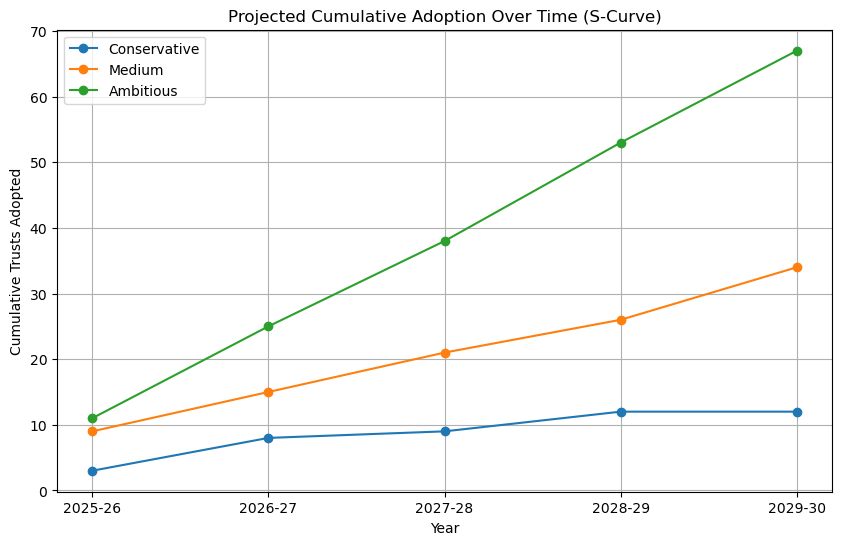

In [99]:
# Step 15: Plot projected S-curves for each scenario
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for scenario in scenarios.keys():
    # Sum adopted trusts per year
    adoption_cum = (
        future_target_df_tidy[future_target_df_tidy['Scenario']==scenario]
        .groupby('Year')['Adopted']
        .sum()
        .cumsum()
    )
    plt.plot(future_years, adoption_cum, marker='o', label=scenario)

plt.title("Projected Cumulative Adoption Over Time (S-Curve)")
plt.xlabel("Year")
plt.ylabel("Cumulative Trusts Adopted")
plt.grid(True)
plt.legend()
plt.show()